### Ejercicio para la Sección 1

**Objetivo**: Comprender cómo se distribuyen los datos antes de aplicar clustering.

**Instrucciones**:

- Genera un dataset con 4 grupos utilizando make_blobs.

- Visualiza los datos en un gráfico de dispersión.

- Reflexiona sobre qué técnica de clustering sería la más adecuada para estos datos.


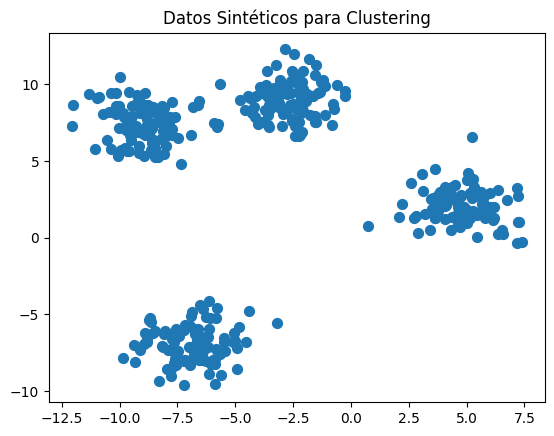

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar dataset sintético con 4 clusters
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=42)

# Graficar los datos sin etiquetas

plt.scatter(X[:, 0], X[:, 1], s=50)

plt.title("Datos Sintéticos para Clustering")
plt.show()

- En cuanto a mi reflexión, considero que la mejor técnica de clustering es K-Means, porque está determinado el número de grupos.

¿Cómo podríamos determinar automáticamente el número óptimo de clusters?

- Se me ocurre por la cantidad de variables, por ejemplo en el dataset de ingresos, el salario de "Senior", "Junior", "Tecnico"
No recuerdo si esas son las variables utilizadas, pero en este caso podríamos darle a K un valor de 3 por la cantidad de agrupamientos en otras variables como en este caso, el nivel técnico.


¿Qué ventajas tiene visualizar los datos antes de aplicar clustering?

- La ventaja que puedo encontrar es el identificar los cambios que realizan estas herramientas de clustering


¿Qué pasaría si los clusters estuvieran muy superpuestos?

- Creo que algunos valores podrían mesclarse o no podría detectar correctamente los agrupamientos


Ejercicio para la Sección 2
Objetivo: Aplicar K-Means a un dataset real y determinar el número óptimo de clusters.

Instrucciones:

Carga el dataset de pingüinos de Seaborn (sns.load_dataset("penguins")).

Selecciona variables numéricas (ejemplo: bill_length_mm, bill_depth_mm).

Usa el método del codo para determinar el mejor K.

Aplica K-Means y visualiza los clusters.

Explica qué insights puedes obtener de la segmentación.


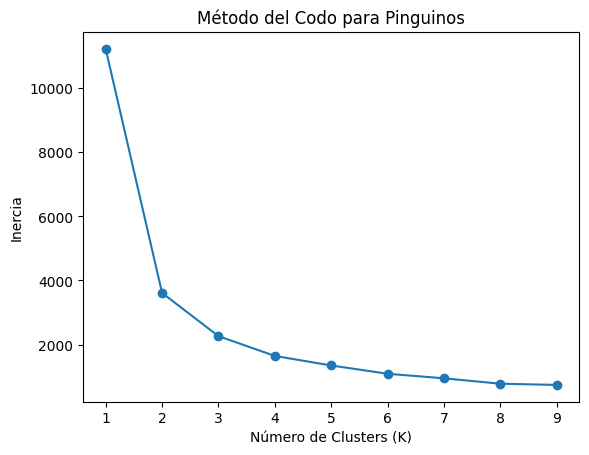

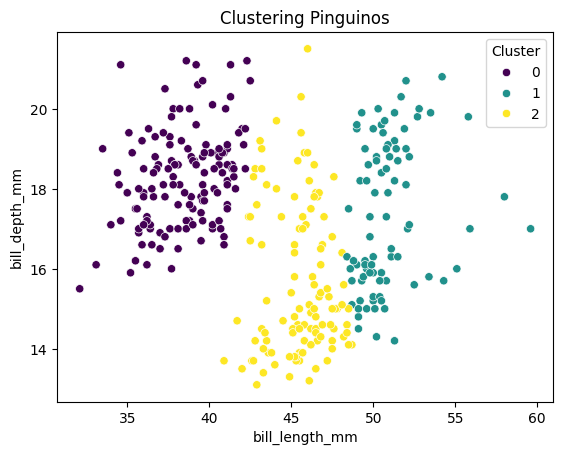

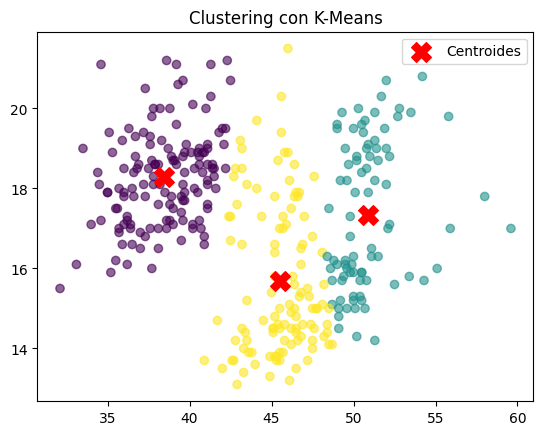

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Cargar dataset de pingüinos
df = sns.load_dataset("penguins").dropna()
X = df[["bill_length_mm", "bill_depth_mm"]]


# Calcular la inercia para diferentes valores de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Pinguinos")
plt.show()

# Aplicar K-Means con un K optimo
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

sns.scatterplot(x=df["bill_length_mm"], y=df["bill_depth_mm"],
                hue=df["Cluster"], palette="viridis")
plt.title("Clustering Pinguinos")
plt.show()

# Graficar clusters y centroides
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")
plt.title("Clustering con K-Means")
plt.legend()
plt.show()


Ejercicio para la Sección 3

**Objetivo**: Aplicar DBScan a un dataset real y comparar los resultados con K-Means.

**Instrucciones**:

Carga el dataset de flores Iris (sns.load_dataset("iris")).

Selecciona dos características (sepal_length y sepal_width).

Aplica DBScan y visualiza los clusters.

Aplica K-Means y compara los resultados.

Explica qué diferencias observas entre ambos métodos.

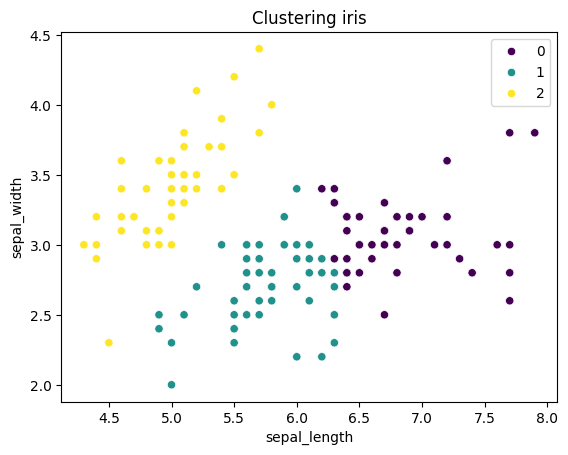

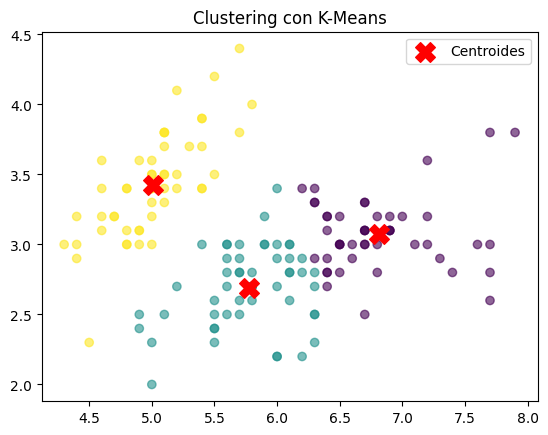

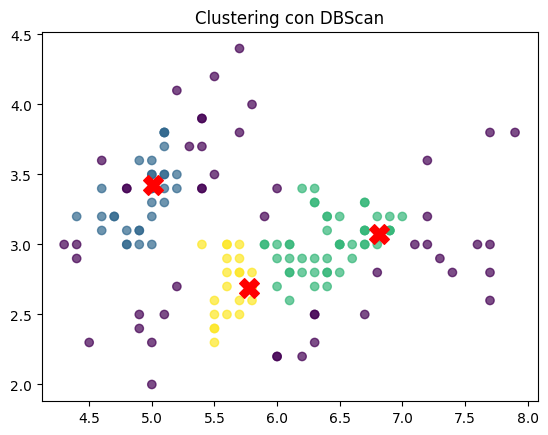

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# Cargar dataset de pingüinos
df = sns.load_dataset("iris").dropna()
X = df[["sepal_length", "sepal_width"]].values

# Aplicar K-Means con un K de 3
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=y_kmeans, palette="viridis")
plt.title("Clustering iris")
plt.show()

# Graficar clusters y centroides
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")
plt.title("Clustering con K-Means")
plt.legend()
plt.show()

# Aplicar DBScan
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X)

# Visualizar resultados
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")

plt.title("Clustering con DBScan")
plt.show()

El primer método (K-Means)realiza agrupamiento según los valores que encuentra al rededor

El segundo método (DBScan) realiza clustering en base a la densidad, esto quiere decir que no requiere espesificar el número de clusters, esto sirve para identificar diferentes areas y manejar outliers más efectiva q K-Means



Ejercicio para la Sección 3

Objetivo: Aplicar DBScan a un dataset real y comparar los resultados con K-Means.

Instrucciones:


Carga el dataset de flores Iris (sns.load_dataset("iris")).

Selecciona dos características (sepal_length y sepal_width).

Aplica DBScan y visualiza los clusters.

Aplica K-Means y compara los resultados.

Explica qué diferencias observas entre ambos métodos.

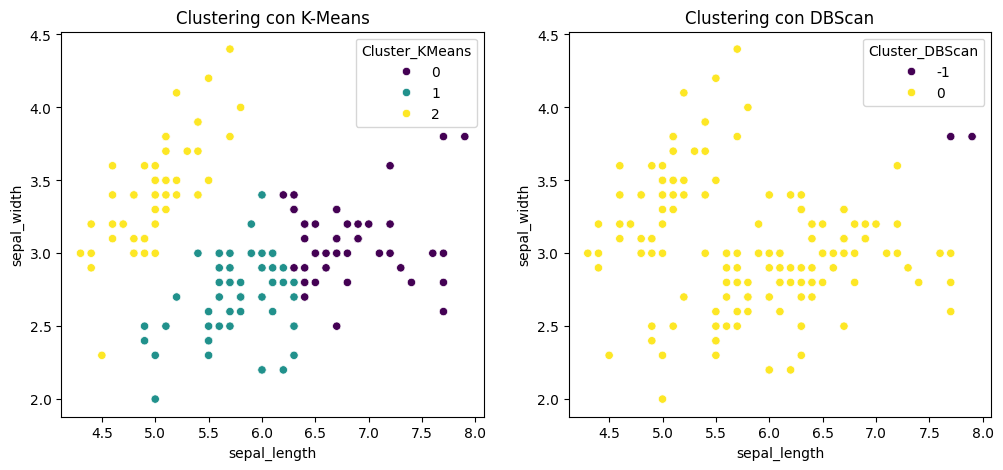

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# Cargar dataset Iris
df = sns.load_dataset("iris")
X = df[["sepal_length", "sepal_width"]].values

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["Cluster_DBScan"] = dbscan.fit_predict(X)

# Visualizar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_KMeans"], palette="viridis")
plt.title("Clustering con K-Means")

plt.subplot(1, 2, 2)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_DBScan"], palette="viridis")
plt.title("Clustering con DBScan")
plt.show()

Preguntas de Reflexión

¿Cuántos clusters detectó DBScan en comparación con K-Means?

DBScan tiene 2 cluesters a comparación de K-means que tiene 3

¿DBScan detectó puntos como outliers? ¿Por qué?

Sí, detecto 2 puntos como outliers en el cluster "-1"
DBScan detectó a estos valores como anormales en comparación a el resto de datos estudiados

¿Qué ventajas ofrece DBScan en este caso?

DBScan nos permite poder visualizar estos datos, que no nos permite K-Means, mientras K-Means nos intenta separar en "tipo de flor", DBScan nos intenta separar la información automáticamente con los Outliers

Ejercicio para la Sección 4

Objetivo: Comparar diferentes algoritmos de clustering con métricas de evaluación.




In [ ]:
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Cargar dataset de diamantes (muestra)
df = sns.load_dataset("diamonds")
X = df[["carat", "price"]].values[:1000]

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X)

# Aplicar DBScan
dbscan = DBSCAN(eps=500, min_samples=5) # Reduced eps from 5000 to 500
labels_db = dbscan.fit_predict(X)

# Métricas
mask = labels_db != -1
print(f"Silhouette - K-Means: {silhouette_score(X, labels_km):.2f}")
print(f"Silhouette - DBScan:  {silhouette_score(X[mask], labels_db[mask]):.2f}")
print(f"Davies-Bouldin - K-Means: {davies_bouldin_score(X, labels_km):.2f}")
print(f"Davies-Bouldin - DBScan:  {davies_bouldin_score(X[mask], labels_db[mask]):.2f}")

Silhouette - K-Means: 0.97
Silhouette - DBScan:  0.98
Davies-Bouldin - K-Means: 0.12
Davies-Bouldin - DBScan:  0.05


¿Cuál algoritmo obtuvo el mejor coeficiente de Silhouette?

El mejor algoritmo es el DBScan teniendo un Silhouette mayor a K-Means

¿El Davies-Bouldin Index confirma los resultados del Silhouette Score?

Si, en este caso lo confirma, DBScan tiene un menor valor de Davies-Bouldin que K-Means.

¿En qué situaciones puede fallar cada métrica?

Considero que K-Means es mejor para los datos agrupados sin embargo DBScan es mucho más precizo para detectar outliers, entonces ambos son para trabajos diferentes, solo se utilizan en diferentes situaciones


**Consigna: Video sobre K-Means y DBSCAN**

Realicen un video breve, de 3 a 5 minutos, en el que expliquen las similitudes y diferencias entre los algoritmos de clustering K-Means y DBSCAN.

El video debe incluir una explicación general de cómo funciona cada algoritmo, qué tipo de agrupamientos realiza, qué parámetros necesita y en qué casos conviene utilizar uno u otro. También deberán mencionar diferencias importantes, como la necesidad de definir previamente la cantidad de clusters en K-Means, el uso de densidad en DBSCAN y la posibilidad de detectar ruido u outliers.

Para la entrega, suban el video a una plataforma como Google Drive, OneDrive o YouTube en modo “no listado”. Luego peguen en Moodle, dentro del espacio de entrega de la tarea, la URL visible del video. Antes de entregar, verifiquen que el enlace funcione correctamente y que pueda abrirse sin solicitar permisos adicionales.